In [1]:
# Import libraries
import sys
import os
import json
import pandas as pd
from pathlib import Path
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Add the src directory to Python path
project_root = Path.cwd().parent.parent  # Go up to bonn_thesis/src/
sys.path.insert(0, str(project_root))

# Set pandas options
pd.set_option('display.max_columns', None)

from bonn_thesis.config import SOEP_DATA_BLD


Load LLM wage predictions

In [2]:
# Define the experiment number you want to load
experiment_num = "14"

# Get all matching files
openai_responses_dir = SOEP_DATA_BLD / "openai_responses"
matching_files = sorted(openai_responses_dir.glob(f"wage_soep_exp_{experiment_num}*.jsonl"))

print(f"Found {len(matching_files)} files for experiment {experiment_num}:")
for file in matching_files:
    print(f"  - {file.name}")

# Load all matching files
openai_data = []
for file_path in matching_files:
    with open(file_path, 'r') as f:
        for line in f:
            openai_data.append(json.loads(line))

print(f"\nTotal responses loaded: {len(openai_data)}")

Found 5 files for experiment 14:
  - wage_soep_exp_14a_results.jsonl
  - wage_soep_exp_14b_results.jsonl
  - wage_soep_exp_14c_results.jsonl
  - wage_soep_exp_14d_results.jsonl
  - wage_soep_exp_14e_results.jsonl

Total responses loaded: 70378


Load SOEP data

In [3]:
# Load SOEP aggregated data
soep_agg_path = SOEP_DATA_BLD / "aggregated" / "soep_agg_part_14.parquet"
soep_df = pd.read_parquet(soep_agg_path)

Extract wages and merge to corresponding SOEP observations

In [4]:
# Extract wage estimates from OpenAI responses
def extract_wage(response_obj):
    """Extract numeric wage from OpenAI response content."""
    try:
        # Get the content from the response
        content = response_obj['response']['body']['choices'][0]['message']['content']
        
        # Remove common text patterns
        content = content.lower()
        content = content.replace('approximately', '')
        content = content.replace('estimate:', '')
        content = content.replace('euros', '')
        content = content.replace('euro', '')
        content = content.replace('€', '')
        content = content.replace(',', '')
        content = content.replace('.', '')
        content = content.strip()
        
        # Extract first number found
        numbers = re.findall(r'\d+', content)
        if numbers:
            wage = float(numbers[0])
            if wage > 10000:
                return wage
        return None
    except:
        return None

# Create DataFrame with custom_id and extracted wages
openai_df = pd.DataFrame([
    {
        'custom_id': item['custom_id'],
        'llm_income': extract_wage(item)
    }
    for item in openai_data
])

print(f"Successfully extracted {openai_df['llm_income'].notna().sum()} wages")

Successfully extracted 70257 wages


In [5]:
# Merge datasets on custom_id
merged_df = openai_df.merge(soep_df, on='custom_id', how='inner')

# Rename variables to remove _mean suffix (individual data, not aggregated)
merged_df = merged_df.rename(columns={
    'pglabgro_mean': 'pglabgro',
    'pgexpft_mean': 'pgexpft'
})

# Remove n_obs column if it exists (all equal to 1 for individual data)
if 'n_obs' in merged_df.columns:
    merged_df = merged_df.drop(columns=['n_obs'])

# Convert annual to monthly wage
merged_df["llm_income"] = merged_df["llm_income"]/12

print(f"Merged dataset has {len(merged_df)} rows")
print(f"\nColumns: {merged_df.columns.tolist()}")
print(f"\nMissing values:")
print(merged_df.isnull().sum())

Merged dataset has 70378 rows

Columns: ['custom_id', 'llm_income', 'hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro', 'pglabnet_mean', 'sex', 'bula_h', 'isco_code', 'isco_3_digit', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit', 'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill', 'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code', 'state_en', 'state_de']

Missing values:
custom_id              0
llm_income           121
hid                    0
pid                    0
syear                  0
pgkldb2010             0
pgisco08               0
pgisced11              0
pgexpft              228
pgemplst               0
pglabgro               0
pglabnet_mean          0
sex                    0
bula_h                 0
isco_code              0
isco_3_digit           0
isco_2_digit           0
isco_1_digit           0
isco_1_name            0
i

## Descriptive statistics & income distributions

In [6]:
# Remove rows with missing wages
valid_df = merged_df.dropna(subset=['llm_income']).copy()

# Filter out zero or negative wages BEFORE taking logs
valid_df = valid_df[
    (valid_df['pglabgro'] > 0) & 
    (valid_df['llm_income'] > 0)
].copy()

# Create log wage variables for analysis
valid_df['log_pglabgro'] = np.log(valid_df['pglabgro'])
valid_df['log_llm_income'] = np.log(valid_df['llm_income'])
valid_df['pgexpft_sq'] = (valid_df['pgexpft'] ** 2)/100

# Compute measurement error
valid_df["measurement_error"] = valid_df['llm_income'] - valid_df['pglabgro']
valid_df["measurement_error_log"] = valid_df['log_llm_income'] - valid_df['log_pglabgro']

# Keep observations where measurement_error_log < 1.50 in absolute value
valid_df = valid_df[valid_df["measurement_error_log"].abs() < 1.5].copy()

# Return only values where pglabgro is greater than 10000/12
valid_df = valid_df[valid_df["pglabgro"] > 10000/12].copy()

print(f"After filtering, valid_df has {len(valid_df)} rows")

print(f"\nWage statistics:")
print(f"    SOEP: mean={valid_df['pglabgro'].mean():.4f}, std={valid_df['pglabgro'].std():.4f}")
print(f"    OpenAI: mean={valid_df['llm_income'].mean():.4f}, std={valid_df['llm_income'].std():.4f}")

print(f"\nLog wage statistics:")
print(f"    Log SOEP: mean={valid_df['log_pglabgro'].mean():.4f}, std={valid_df['log_pglabgro'].std():.4f}")
print(f"    Log OpenAI: mean={valid_df['log_llm_income'].mean():.4f}, std={valid_df['log_llm_income'].std():.4f}")

After filtering, valid_df has 68677 rows

Wage statistics:
    SOEP: mean=3521.5316, std=2134.9307
    OpenAI: mean=3104.8346, std=1402.7562

Log wage statistics:
    Log SOEP: mean=8.0314, std=0.5039
    Log OpenAI: mean=7.9607, std=0.3867


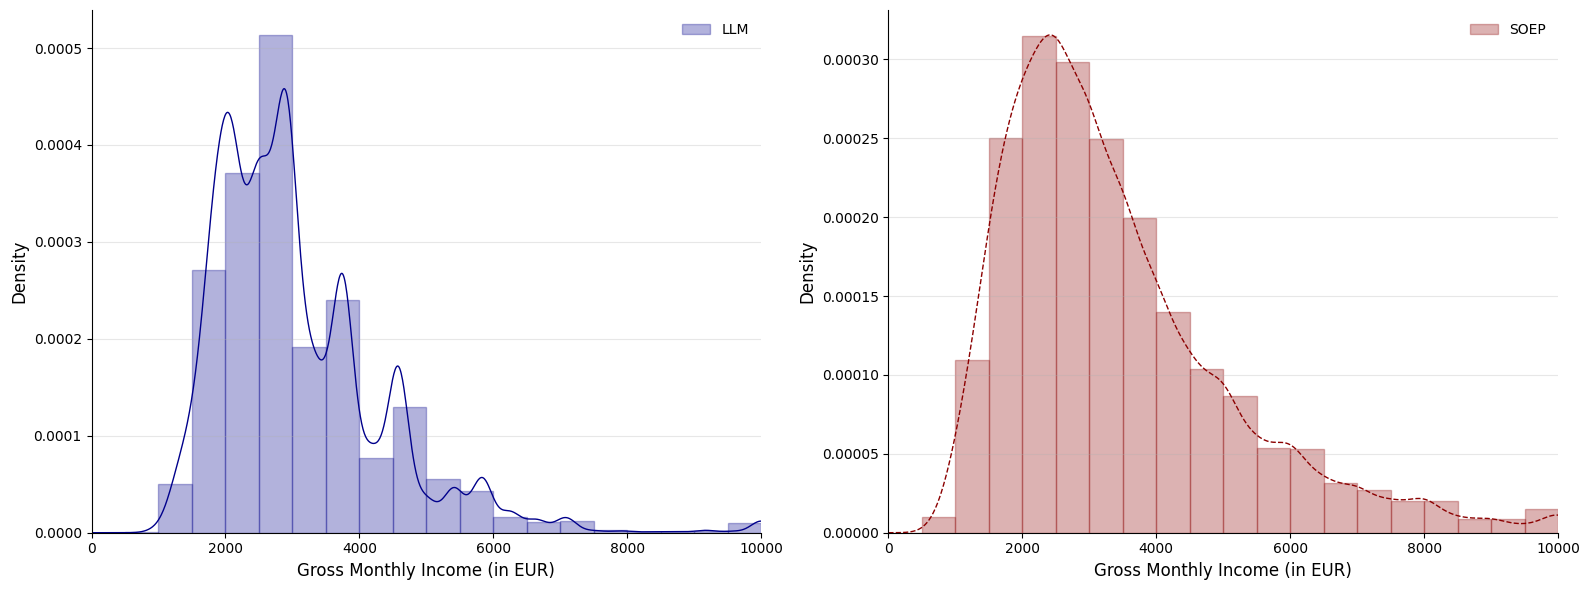

In [7]:
# Plot wage distributions with 500 euro bins and density functions
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define bins of 500 euros
min_wage = 0
max_wage = 10000
bins = np.arange(0, max_wage + 500, 500)

# Plot OpenAI wage distribution
counts, _, patches = axes[0].hist(valid_df['llm_income'], bins=bins, 
                                   alpha=0.3, color='darkblue', edgecolor='darkblue', label='LLM', density=True)
# Add KDE
kde_openai = gaussian_kde(valid_df['llm_income'])
x_range_openai = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_openai, kde_openai(x_range_openai), color='darkblue', linewidth=1, linestyle='-')
axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(frameon=False, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Plot SOEP wage distribution
counts, _, patches = axes[1].hist(valid_df['pglabgro'], bins=bins, 
                                   alpha=0.3, color='darkred', edgecolor='darkred', label='SOEP', density=True)
# Add KDE
kde_soep = gaussian_kde(valid_df['pglabgro'])
x_range = np.linspace(0, 10000, 1000)
axes[1].plot(x_range, kde_soep(x_range), color='darkred', linewidth=1, linestyle='--')
axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].legend(frameon=False, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

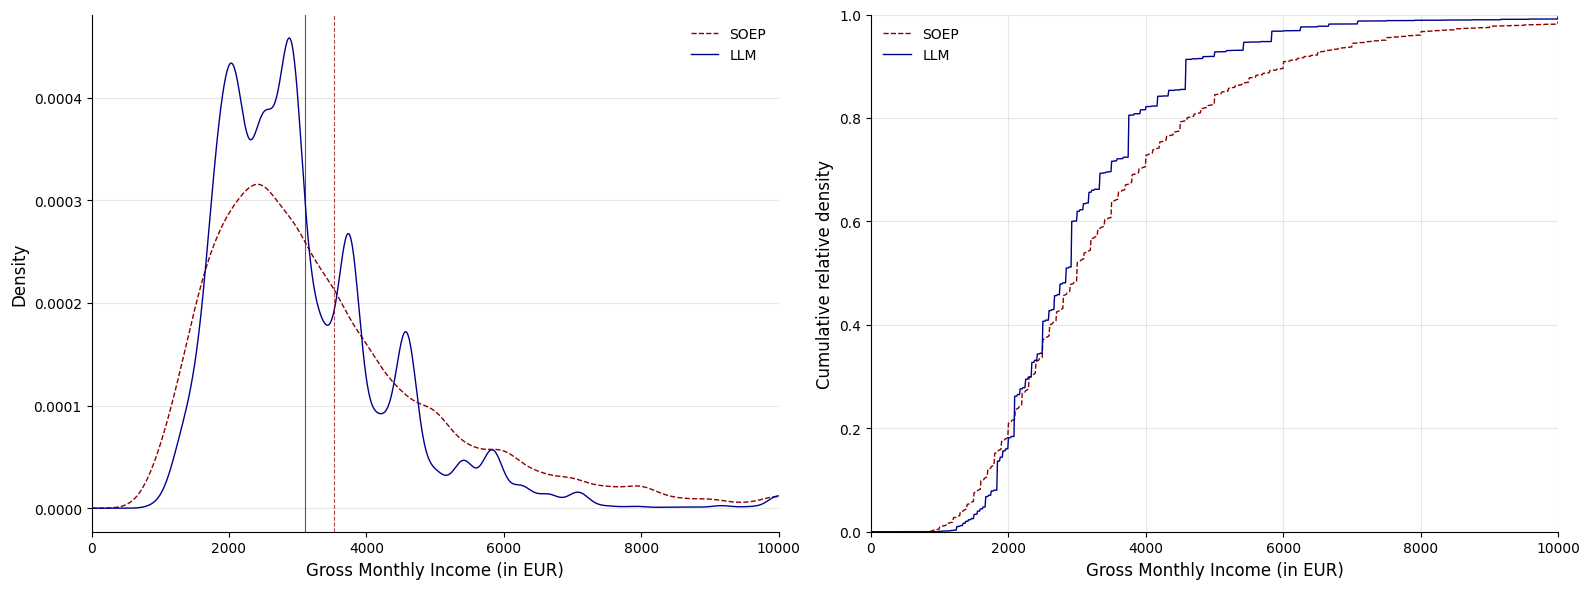

In [8]:
# Create density and cumulative density plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate averages
soep_mean = valid_df['pglabgro'].mean()
openai_mean = valid_df['llm_income'].mean()

# Left panel: Density functions only
x_range_plot = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_plot, kde_soep(x_range_plot), color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[0].plot(x_range_plot, kde_openai(x_range_plot), color='darkblue', linewidth=1, linestyle='-', label='LLM')

# Add vertical lines for averages
axes[0].axvline(soep_mean, color='darkred', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].axvline(openai_mean, color='darkblue', linewidth=0.8, linestyle='-', alpha=0.7)

axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Cumulative density functions
# Calculate empirical CDFs
def empirical_ecdf(data, x_eval):
    """Calculate empirical CDF at evaluation points."""
    sorted_data = np.sort(data)
    n = len(sorted_data)
    
    # Evaluate at x_eval points
    cdf_values = np.searchsorted(sorted_data, x_eval, side='right') / n
    
    return cdf_values

cdf_soep = empirical_ecdf(valid_df['pglabgro'].values, x_range_plot)
cdf_openai = empirical_ecdf(valid_df['llm_income'].values, x_range_plot)

axes[1].plot(x_range_plot, cdf_soep, color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[1].plot(x_range_plot, cdf_openai, color='darkblue', linewidth=1, linestyle='-', label='LLM')

axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Cumulative relative density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation between SOEP and LLM income data

In [9]:
# Compute correlation coefficient

correlation = valid_df['llm_income'].corr(valid_df['pglabgro'])

print(f"Correlation coefficient: {correlation:.4f}")
print(f"\nNumber of observations: {len(valid_df)}")

Correlation coefficient: 0.5893

Number of observations: 68677


## Income ranking (SOEP vs LLM)

In [10]:
# Compute spearman rank correlation
from scipy.stats import spearmanr

spearman_unweighted = valid_df[['llm_income', 'pglabgro']].corr(method='spearman')
unweighted_rho = spearman_unweighted.loc['llm_income', 'pglabgro']

print(f"Spearman correlation coefficient (unweighted): {unweighted_rho:.4f}")


Spearman correlation coefficient (unweighted): 0.6103


## Measurement error distributions
Measurement error is defined as the difference between LLM estimates and the true survey labor income.

In [11]:
# Measurement error descriptives
me = valid_df['measurement_error']
me_log = valid_df['measurement_error_log']

print(f"Number of observations: {len(me_log)}")

print("Measurement Error Statistics (EUR):")
print(f"  Mean: {me.mean():.4f}")
print(f"  Median: {me.median():.4f}")
print(f"  Std: {me.std():.4f}")
print(f"  Min: {me.min():.4f}")
print(f"  Max: {me.max():.4f}")

print("\nMeasurement Error Statistics (log points):")
print(f"  Mean: {me_log.mean():.4f}")
print(f"  Median: {me_log.median():.4f}")
print(f"  Std: {me_log.std():.4f}")
print(f"  Min: {me_log.min():.4f}")
print(f"  Max: {me_log.max():.4f}")

Number of observations: 68677
Measurement Error Statistics (EUR):
  Mean: -416.6969
  Median: -186.6667
  Std: 1730.9405
  Min: -33024.6667
  Max: 11500.0000

Measurement Error Statistics (log points):
  Mean: -0.0707
  Median: -0.0690
  Std: 0.4021
  Min: -1.4958
  Max: 1.4961


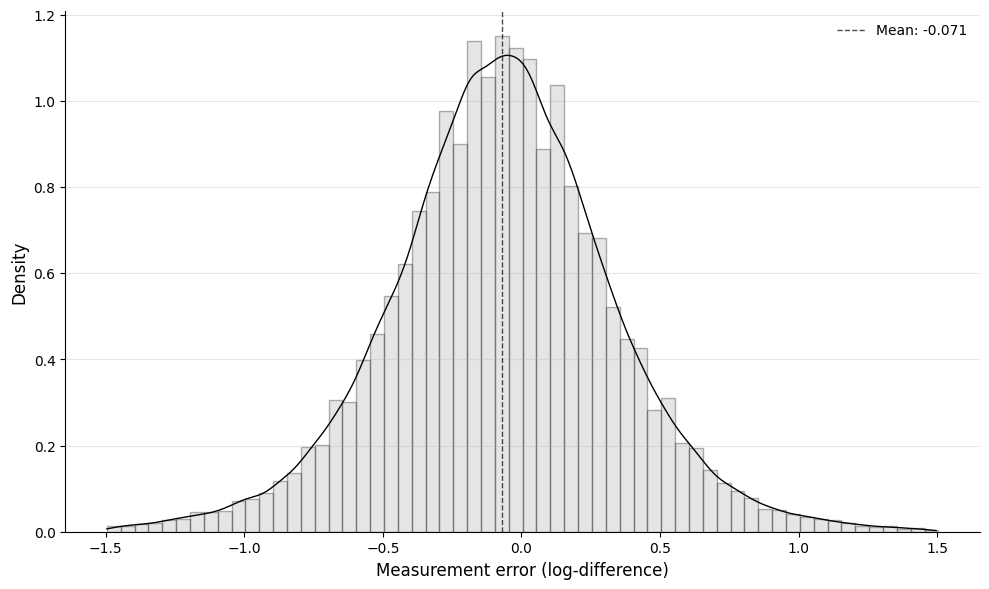

In [12]:
# Plot measurement error distribution in logs
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate mean of measurement error
me_mean = valid_df['measurement_error_log'].mean()

# Define bins of 0.05
bins = np.arange(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max() + 0.05, 0.05)

# Plot histogram
ax.hist(valid_df['measurement_error_log'], bins=bins, 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error_log'])
x_range = np.linspace(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max(), 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.3f}')

ax.set_xlabel('Measurement error (log-difference)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

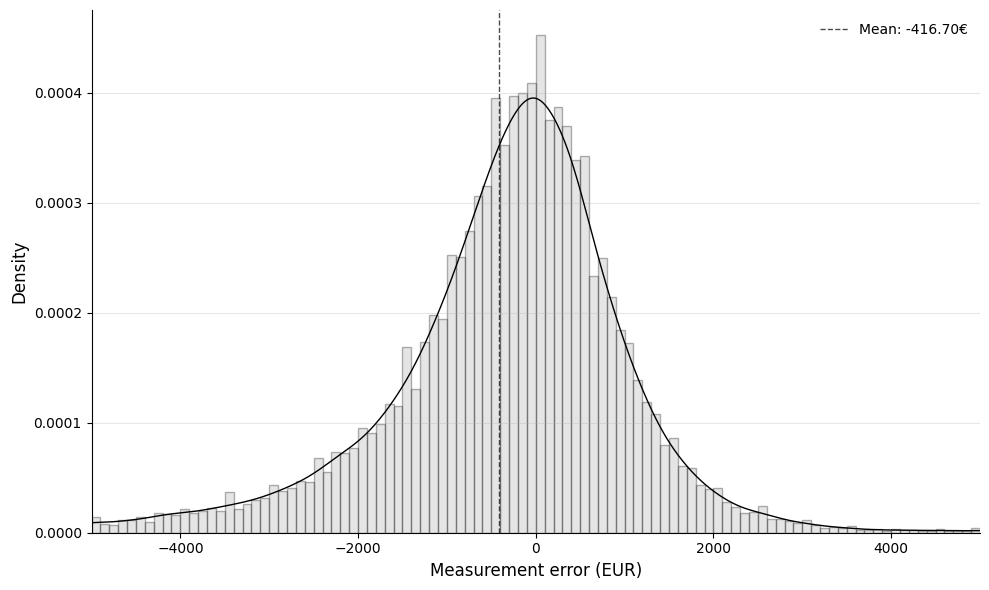

In [13]:
# Plot nominal measurement error distribution
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate mean of measurement error
me_mean = valid_df['measurement_error'].mean()

# Define bins (100 euro bins) and limit range to -5000 to +5000
bin_width = 100
bins = np.arange(-5000, 5000 + bin_width, bin_width)

# Plot histogram
ax.hist(valid_df['measurement_error'], bins=bins, 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error'])
x_range = np.linspace(-5000, 5000, 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.2f}€')

ax.set_xlabel('Measurement error (EUR)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-5000, 5000)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_16748/2321978072.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_euro = valid_df.groupby('income_quantile').agg({
/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_16748/2321978072.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_log = valid_df.groupby('income_quantile').agg({


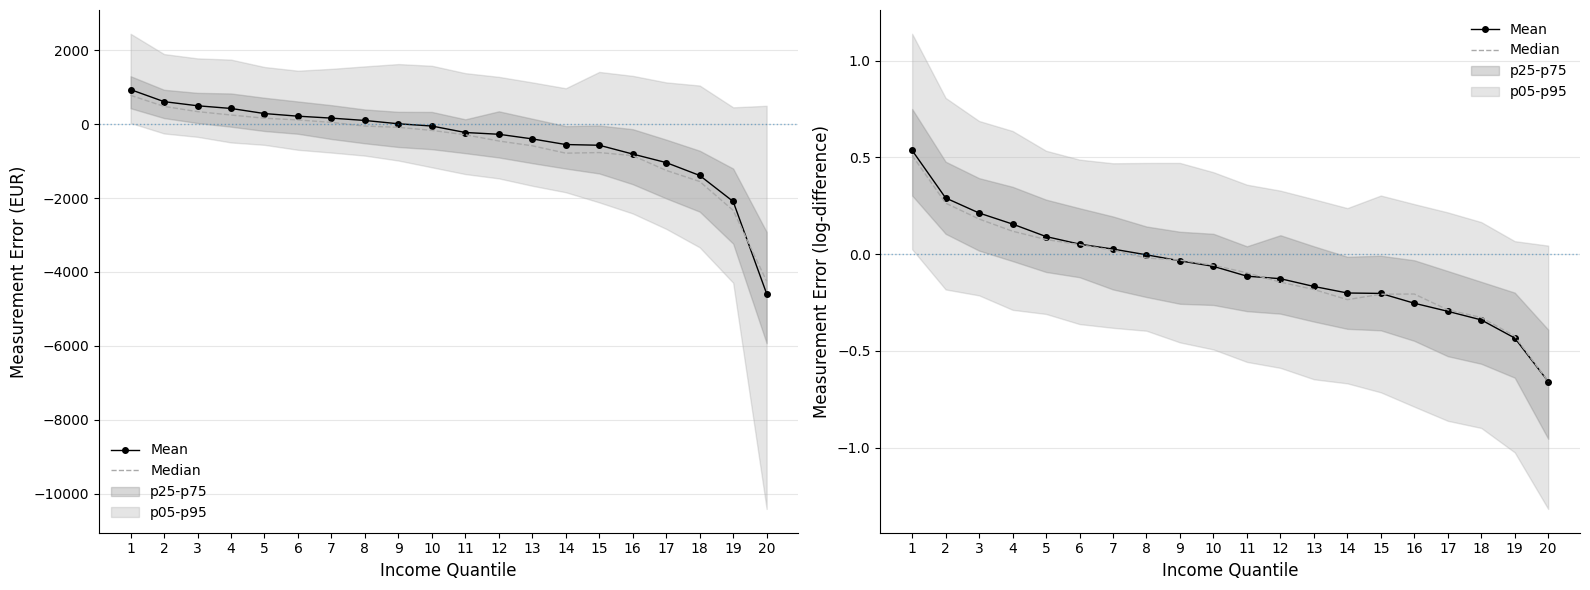

In [14]:
# Measurement error distribution by earning quantiles

# Create 20 quantiles based on SOEP earnings
valid_df['income_quantile'] = pd.qcut(valid_df['pglabgro'], q=20, labels=range(1, 21))

# Calculate statistics for each quantile (in euros)
quantile_stats_euro = valid_df.groupby('income_quantile').agg({
    'measurement_error': ['mean', 'median', 
                          lambda x: x.quantile(0.05),
                          lambda x: x.quantile(0.25), 
                          lambda x: x.quantile(0.75),
                          lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_euro.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Calculate statistics for each quantile (in logs)
quantile_stats_log = valid_df.groupby('income_quantile').agg({
    'measurement_error_log': ['mean', 'median',
                              lambda x: x.quantile(0.05),
                              lambda x: x.quantile(0.25),
                              lambda x: x.quantile(0.75),
                              lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_log.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Measurement error in euros
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p05'], quantile_stats_euro['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p25'], quantile_stats_euro['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['mean'], 
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[0].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Income Quantile', fontsize=12)
axes[0].set_ylabel('Measurement Error (EUR)', fontsize=12)
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[0].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[0].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error in logs
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p05'], quantile_stats_log['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p25'], quantile_stats_log['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['mean'],
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[1].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Income Quantile', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].set_xticks(range(1, 21))
axes[1].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[1].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[1].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation with observables and Mincer regressions

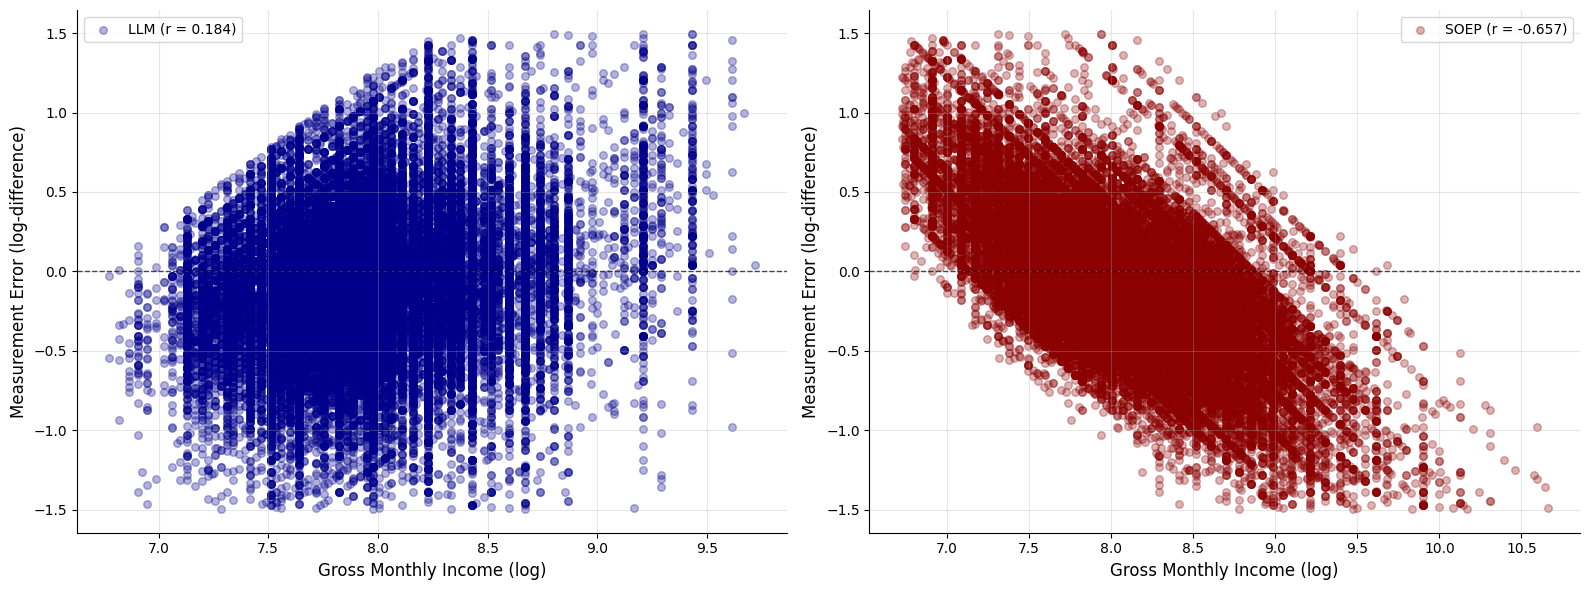

In [15]:
# Scatter plot: Measurement error vs income levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate correlations
corr_llm = valid_df['log_llm_income'].corr(valid_df['measurement_error_log'])
corr_soep = valid_df['log_pglabgro'].corr(valid_df['measurement_error_log'])

# Left panel: Measurement error vs LLM income
axes[0].scatter(valid_df['log_llm_income'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkblue', s=30, label=f'LLM (r = {corr_llm:.3f})')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[0].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[0].legend(fontsize=10, frameon=True)
axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error vs SOEP income
axes[1].scatter(valid_df['log_pglabgro'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkred', s=30, label=f'SOEP (r = {corr_soep:.3f})')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].legend(fontsize=10, frameon=True)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
valid_df['llm_income'].value_counts().head(50)

llm_income
2916.666667     6058
3750.000000     5577
2083.333333     5346
2500.000000     4230
4583.333333     3988
1833.333333     3863
3333.333333     2118
2833.333333     1966
2333.333333     1932
2666.666667     1851
2000.000000     1471
3166.666667     1423
2750.000000     1413
1666.666667     1388
3500.000000     1382
5833.333333     1378
4166.666667     1301
3000.000000     1287
2583.333333     1260
2250.000000     1119
5416.666667     1055
2416.666667      842
1916.666667      834
3083.333333      803
2166.666667      748
4333.333333      741
5000.000000      607
1750.000000      571
1500.000000      557
1875.000000      516
3916.666667      515
6250.000000      485
1250.000000      464
4000.000000      421
1541.666667      415
7083.333333      386
10000.000000     310
1333.333333      298
2291.666667      296
1583.333333      291
6666.666667      285
3583.333333      274
2375.000000      268
1958.333333      267
3208.333333      266
4833.333333      260
1375.000000      252
16

In [17]:
# Prepare dataframes

covariates = ['sex_en', 'education_grouped', 'state_en', 'isco_3_name', 'syear', 'pgexpft', 'pgexpft_sq']

# Prepare the data for regression - drop any rows with missing values in key variables
regression_df = valid_df[['measurement_error_log', 'log_llm_income', 'log_pglabgro'] + covariates].dropna().copy()
regression_df['syear'] = regression_df['syear'].astype(str)

print(f"Observations for regression: {len(regression_df)}")

Observations for regression: 68452


In [18]:
# Regression of measurement error (log) on covariates

# Combine all features
X = pd.get_dummies(regression_df[covariates], drop_first=True, dtype=float)

# Add constant
X = sm.add_constant(X)

# Dependent variable
y = regression_df['measurement_error_log'].values

# Fit OLS with robust standard errors
model = sm.OLS(y, X)
results = model.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("OLS Regression: Measurement Error (log) on Covariates")
print("="*80)
print(results.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results.params)) if i != 0]
f_test = results.f_test(np.eye(len(results.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test.fvalue:.4f}")
print(f"P-value: {f_test.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred = results.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print("="*80)

OLS Regression: Measurement Error (log) on Covariates
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     134.6
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:41:29   Log-Likelihood:                -27220.
No. Observations:               68452   AIC:                         5.474e+04
Df Residuals:                   68302   BIC:                         5.611e+04
Df Model:                         149                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025      0

In [19]:
# Regression of log_llm_income on covariates
# Using the same feature matrix X from the previous regression

# Dependent variable - log LLM income
y_llm = regression_df['log_llm_income'].values

# Fit OLS with robust standard errors (using same X)
model_llm = sm.OLS(y_llm, X)
results_llm = model_llm.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("OLS Regression: log(LLM Income) on Covariates")
print("="*80)
print(results_llm.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_llm.params)) if i != 0]
f_test_llm = results_llm.f_test(np.eye(len(results_llm.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_llm.fvalue:.4f}")
print(f"P-value: {f_test_llm.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_llm.rsquared:.4f}")
print(f"Adjusted R-squared: {results_llm.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_llm = results_llm.predict(X)
rmse_llm = np.sqrt(mean_squared_error(y_llm, y_pred_llm))
mae_llm = mean_absolute_error(y_llm, y_pred_llm)

print(f"RMSE: {rmse_llm:.4f}")
print(f"MAE: {mae_llm:.4f}")
print("="*80)

OLS Regression: log(LLM Income) on Covariates
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     3035.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:41:30   Log-Likelihood:                 41257.
No. Observations:               68452   AIC:                        -8.221e+04
Df Residuals:                   68302   BIC:                        -8.084e+04
Df Model:                         149                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--

In [20]:
# Regression of log_pglabgro (SOEP wages) on covariates
# Using the same feature matrix X from the previous regressions

# Dependent variable - log SOEP income
y_soep = regression_df['log_pglabgro'].values

# Fit OLS with robust standard errors (using same X)
model_soep = sm.OLS(y_soep, X)
results_soep = model_soep.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("OLS Regression: log(SOEP Income) on Covariates")
print("="*80)
print(results_soep.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_soep.params)) if i != 0]
f_test_soep = results_soep.f_test(np.eye(len(results_soep.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_soep.fvalue:.4f}")
print(f"P-value: {f_test_soep.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_soep = results_soep.predict(X)
rmse_soep = np.sqrt(mean_squared_error(y_soep, y_pred_soep))
mae_soep = mean_absolute_error(y_soep, y_pred_soep)

print(f"RMSE: {rmse_soep:.4f}")
print(f"MAE: {mae_soep:.4f}")
print("="*80)

OLS Regression: log(SOEP Income) on Covariates
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     574.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:41:32   Log-Likelihood:                -23014.
No. Observations:               68452   AIC:                         4.633e+04
Df Residuals:                   68302   BIC:                         4.770e+04
Df Model:                         149                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-

In [21]:
# Create comparison table of regression results

# Function to format coefficient with std error and significance
def format_coef(coef, se, pval):
    """Format coefficient with standard error and significance stars"""
    stars = ''
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    return f"{coef:.4f}{stars}\n({se:.4f})"

# Extract parameters from all three models
params_me = results.params
se_me = results.bse
pval_me = results.pvalues

params_llm = results_llm.params
se_llm = results_llm.bse
pval_llm = results_llm.pvalues

params_soep = results_soep.params
se_soep = results_soep.bse
pval_soep = results_soep.pvalues

# Create list of rows for the table
table_data = []

# Group variables by type
sex_vars = [v for v in params_me.index if v.startswith('sex_')]
education_vars = [v for v in params_me.index if v.startswith('education_')]
occupation_vars = [v for v in params_me.index if v.startswith('occupation_')]
state_vars = [v for v in params_me.index if v.startswith('state_')]
year_vars = [v for v in params_me.index if v.startswith('syear_')]
experience_vars = ['pgexpft_mean', 'pgexpft_mean_sq']

# Add constant
if 'const' in params_me.index:
    table_data.append({
        'Variable': 'Constant',
        'Measurement Error': format_coef(params_me['const'], se_me['const'], pval_me['const']),
        'LLM Income': format_coef(params_llm['const'], se_llm['const'], pval_llm['const']),
        'SOEP Income': format_coef(params_soep['const'], se_soep['const'], pval_soep['const'])
    })

# Add experience variables
table_data.append({'Variable': '--- Experience ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
for var in experience_vars:
    if var in params_me.index:
        table_data.append({
            'Variable': var,
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add sex variables
if sex_vars:
    table_data.append({'Variable': '--- Sex ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in sex_vars:
        table_data.append({
            'Variable': var.replace('sex_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add education variables
if education_vars:
    table_data.append({'Variable': '--- Education ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in education_vars:
        table_data.append({
            'Variable': var.replace('education_grouped_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 occupation variables by absolute coefficient value (using measurement error)
if occupation_vars:
    occ_abs_coefs = {var: abs(params_me[var]) for var in occupation_vars}
    top_5_occ = sorted(occ_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- Occupation (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_occ:
        table_data.append({
            'Variable': var.replace('occupation_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 state variables by absolute coefficient value (using measurement error)
if state_vars:
    state_abs_coefs = {var: abs(params_me[var]) for var in state_vars}
    top_5_state = sorted(state_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- State (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_state:
        table_data.append({
            'Variable': var.replace('state_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add model statistics
table_data.append({'Variable': '', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
table_data.append({'Variable': '--- Model Statistics ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})

# Time fixed effects
time_fe = 'Yes' if year_vars else 'No'
table_data.append({
    'Variable': 'Time Fixed Effects',
    'Measurement Error': time_fe,
    'LLM Income': time_fe,
    'SOEP Income': time_fe
})

# F-statistic
table_data.append({
    'Variable': 'F-statistic',
    'Measurement Error': f"{f_test.fvalue:.2f}",
    'LLM Income': f"{f_test_llm.fvalue:.2f}",
    'SOEP Income': f"{f_test_soep.fvalue:.2f}"
})

# R-squared
table_data.append({
    'Variable': 'R-squared',
    'Measurement Error': f"{results.rsquared:.4f}",
    'LLM Income': f"{results_llm.rsquared:.4f}",
    'SOEP Income': f"{results_soep.rsquared:.4f}"
})

# Number of observations
table_data.append({
    'Variable': 'Observations',
    'Measurement Error': f"{int(results.nobs)}",
    'LLM Income': f"{int(results_llm.nobs)}",
    'SOEP Income': f"{int(results_soep.nobs)}"
})

# Create DataFrame and display
comparison_table = pd.DataFrame(table_data)
print("="*100)
print("REGRESSION RESULTS COMPARISON")
print("="*100)
print("\nNote: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05")
print("\n")
print(comparison_table.to_string(index=False))
print("\n" + "="*100)

REGRESSION RESULTS COMPARISON

Note: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05


                                                     Variable    Measurement Error           LLM Income          SOEP Income
                                                     Constant  -0.0519**\n(0.0195)  7.9791***\n(0.0055)  8.0310***\n(0.0191)
                                           --- Experience ---                                                               
                                                  --- Sex ---                                                               
                                                      en_male -0.0657***\n(0.0036)  0.0713***\n(0.0013)  0.1370***\n(0.0034)
                                            --- Education ---                                                               
                                    Master or Doctoral degree  0.0466***\n(0.0059)  0.1534***\n(0.0023)  0.1068***\n(0.0055)
Post-secondary non-te

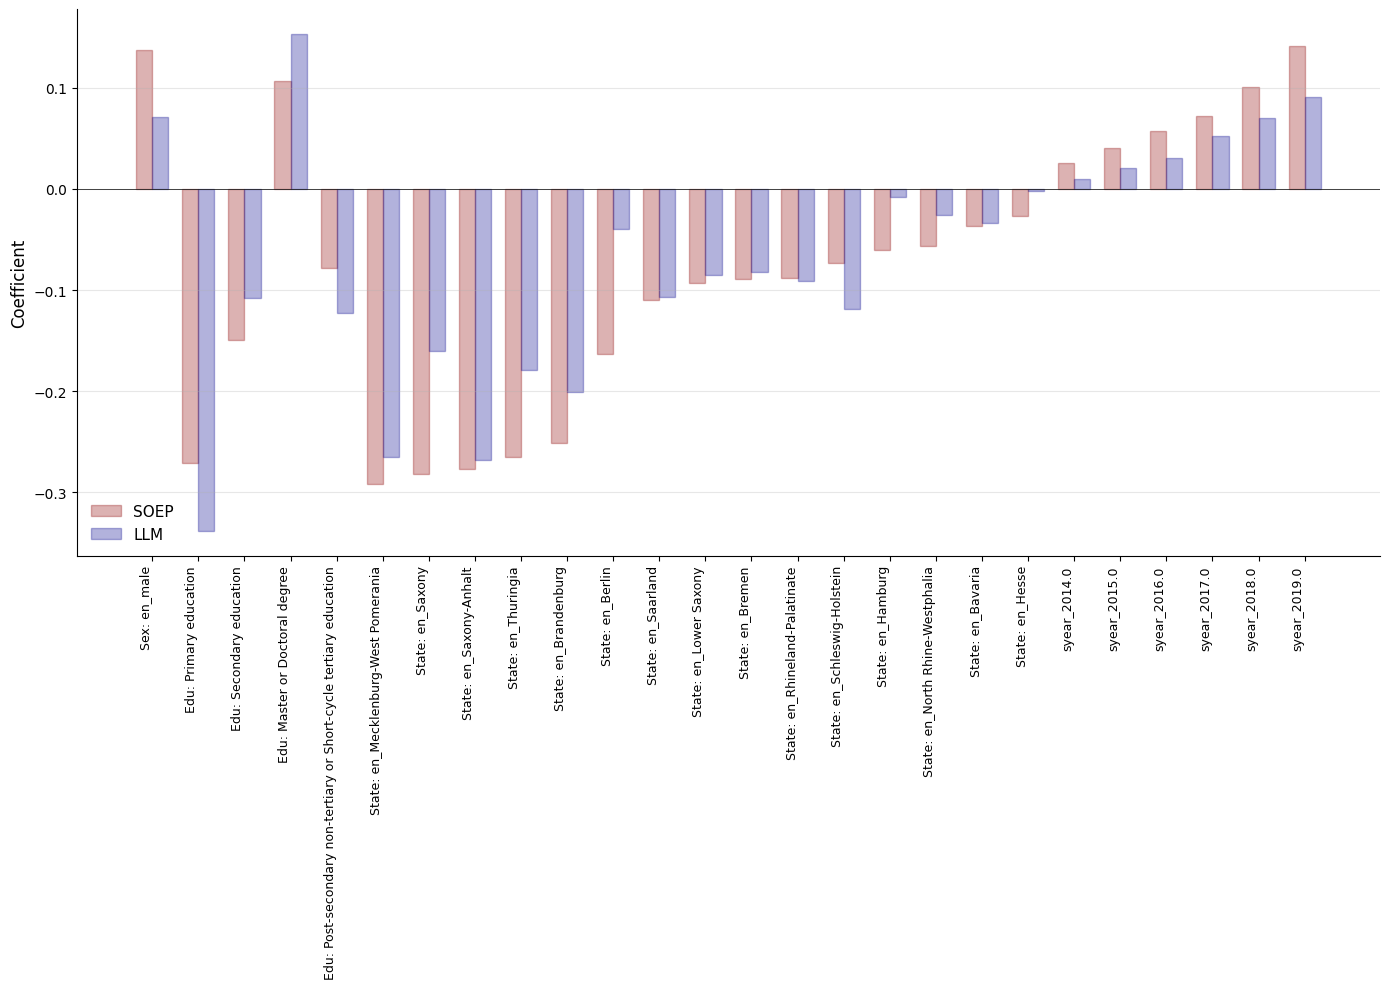

In [22]:
# Visualize coefficient comparison between LLM and SOEP

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_mean_sq']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute SOEP coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_soep[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_soep[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars

# Create labels (clean variable names)
labels = []
llm_coefs = []
soep_coefs = []

for var in plot_vars:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_mean_sq':
            label = 'Experience²'
        elif var == 'syear_':
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

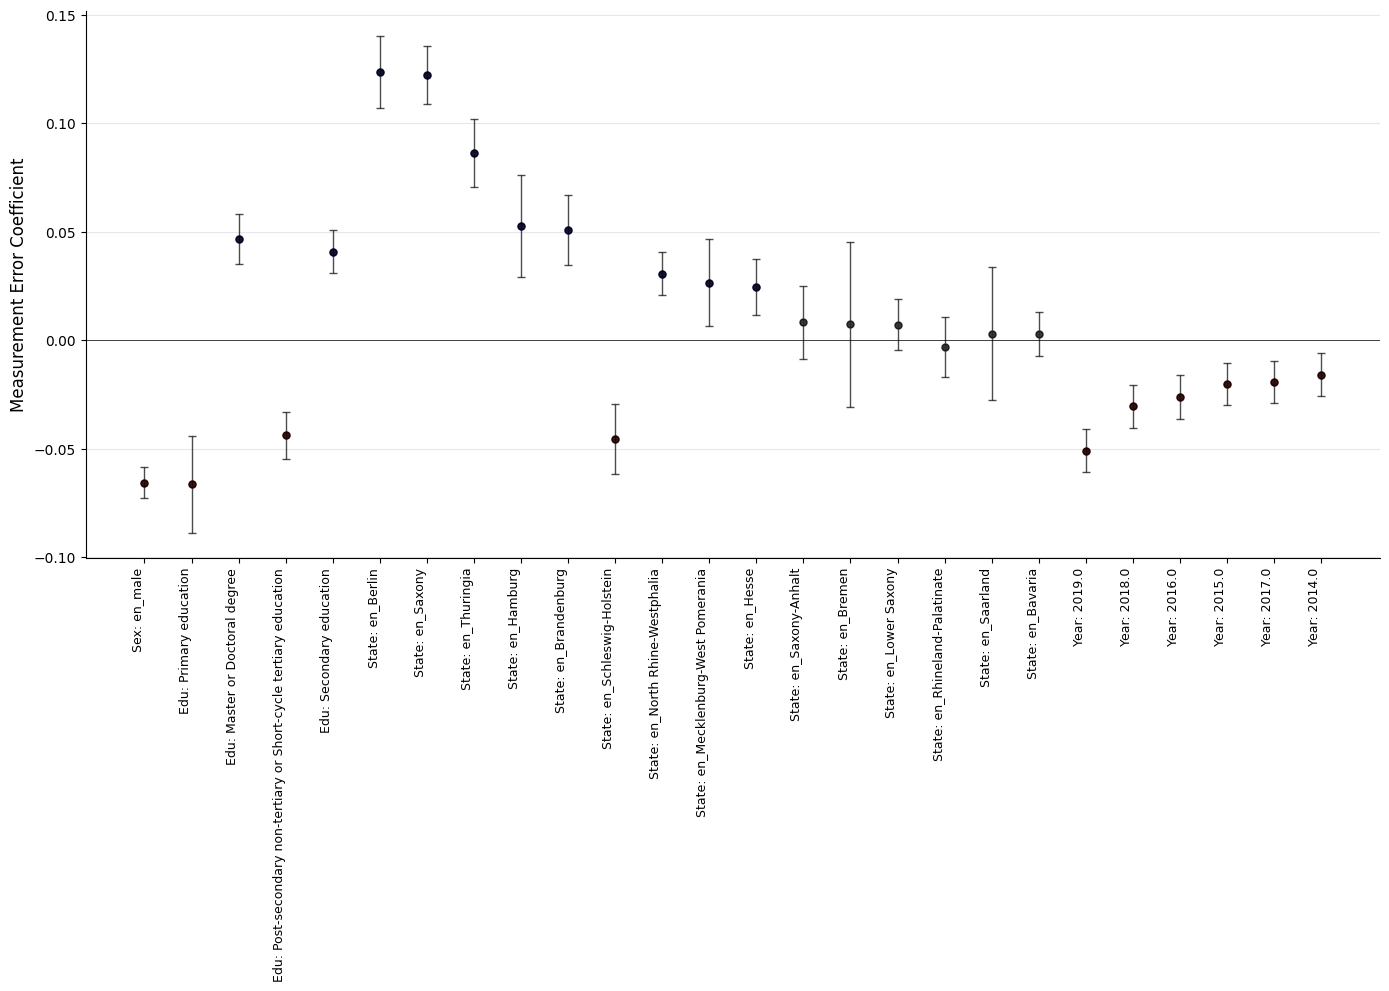

In [23]:
# Visualize measurement error coefficients with confidence intervals

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_mean_sq']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute measurement error coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_me[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_me[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_me[x]), reverse=True)
year_vars_sorted = sorted(year_vars, key=lambda x: abs(params_me[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars_sorted

# Create labels and extract coefficients with standard errors
labels = []
me_coefs = []
me_se = []

for var in plot_vars:
    if var in params_me.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_mean_sq':
            label = 'Experience²'
        elif var.startswith('syear_'):
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        me_coefs.append(params_me[var])
        me_se.append(se_me[var])

# Convert to arrays
me_coefs = np.array(me_coefs)
me_se = np.array(me_se)

# Calculate 95% confidence intervals (1.96 * SE)
ci_95 = 1.96 * me_se

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up positions
x = np.arange(len(labels))

# Plot coefficients with error bars
# Color points based on whether CI includes zero
colors = ['darkgrey' if (coef - ci < 0 and coef + ci > 0) else ('darkred' if coef < 0 else 'darkblue') 
          for coef, ci in zip(me_coefs, ci_95)]

ax.errorbar(x, me_coefs, yerr=ci_95, fmt='o', color='black', ecolor='black', 
            capsize=3, capthick=1, markersize=5, linewidth=1, alpha=0.7)

# Color the points
for i, (xi, yi, color) in enumerate(zip(x, me_coefs, colors)):
    ax.plot(xi, yi, 'o', color=color, markersize=5, alpha=0.7)

# Customize plot
ax.set_ylabel('Measurement Error Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

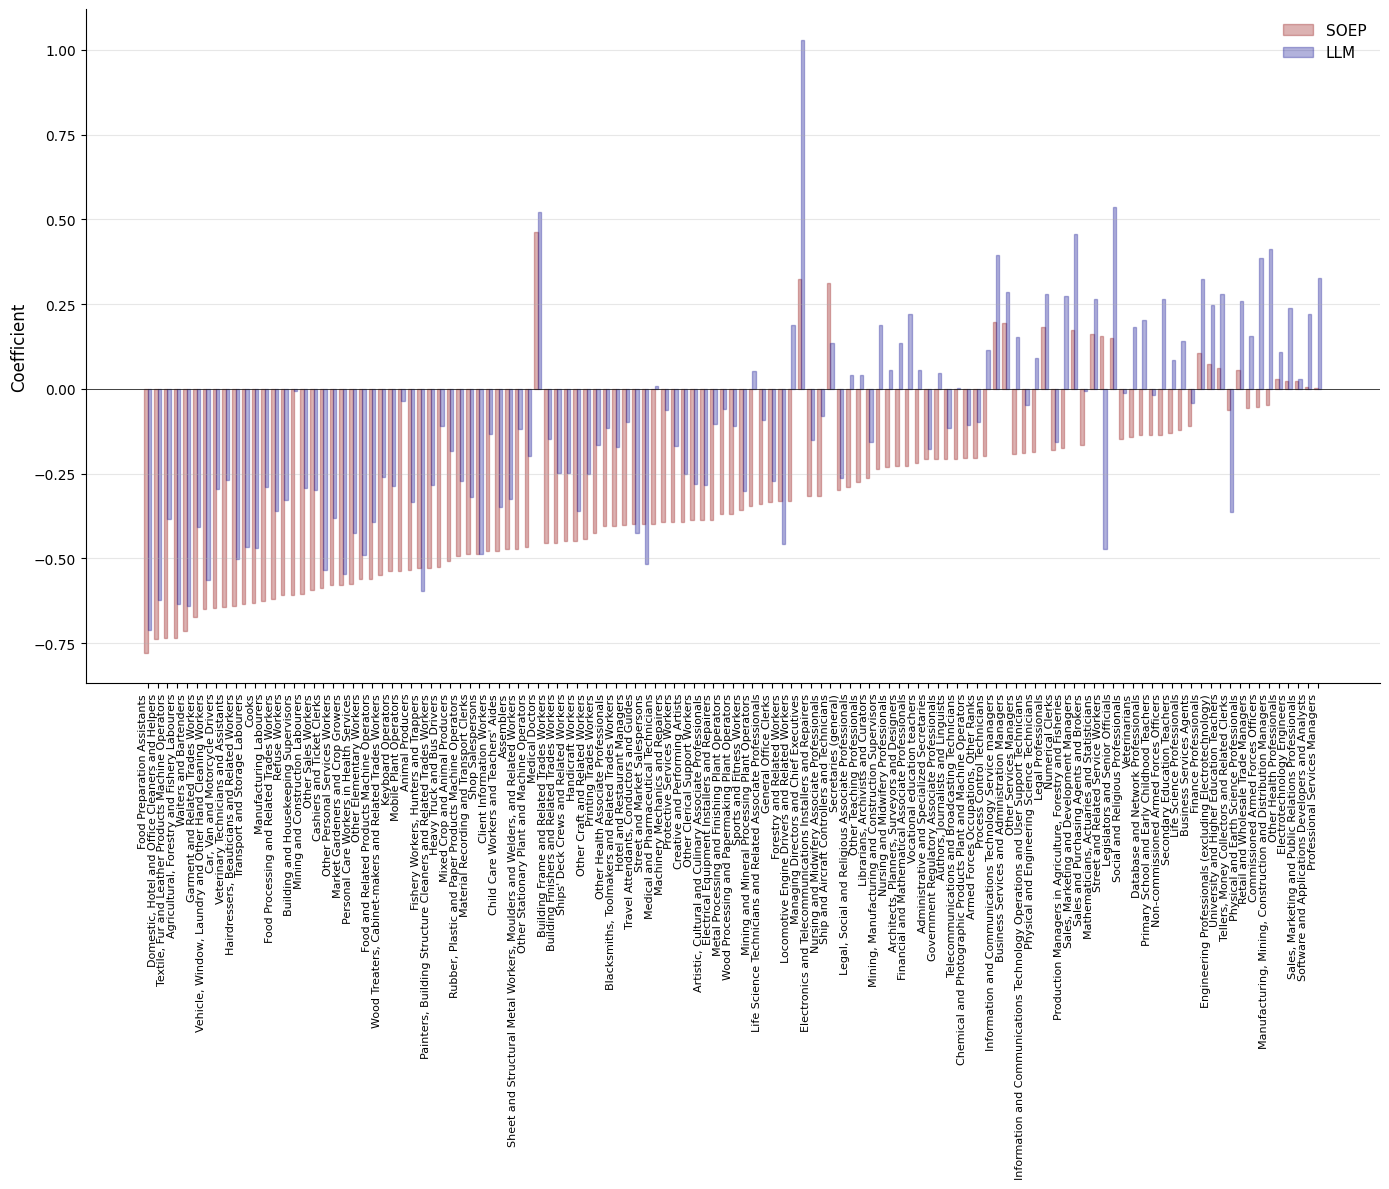

In [24]:
# Visualize coefficient comparison between LLM and SOEP for occupations

# Extract occupation variables
occupation_vars = [v for v in params_llm.index if v.startswith('isco_3_name_')]

# Sort by absolute SOEP coefficient value
occupation_vars_sorted = sorted(occupation_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Create labels and extract coefficients
labels = []
llm_coefs = []
soep_coefs = []

for var in occupation_vars_sorted:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        label = var.replace('isco_3_name_', '')
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=8)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
valid_df_sorted = valid_df.copy()
valid_df_sorted['abs_measurement_error_log'] = valid_df_sorted['measurement_error_log'].abs()
valid_df_sorted = valid_df_sorted.sort_values('pglabgro', ascending=False)

In [26]:
valid_df.columns

Index(['custom_id', 'llm_income', 'hid', 'pid', 'syear', 'pgkldb2010',
       'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro',
       'pglabnet_mean', 'sex', 'bula_h', 'isco_code', 'isco_3_digit',
       'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name',
       'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit',
       'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill',
       'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code',
       'state_en', 'state_de', 'log_pglabgro', 'log_llm_income', 'pgexpft_sq',
       'measurement_error', 'measurement_error_log', 'income_quantile'],
      dtype='object')

In [27]:
# Display top rows
valid_df_sorted[valid_df_sorted["pgexpft"] < 5][["measurement_error_log","measurement_error", "llm_income", "pglabgro", "isco_3_name","syear", "education_grouped", "pgexpft"]].head(500)

,measurement_error_log,measurement_error,llm_income,pglabgro,isco_3_name,syear,education_grouped,pgexpft
37512,-1.276987,-11851.666667,4583.333333,16435.0,Engineering Professionals (excluding Electrote...,2016.0,Bachelor degree,4.167
59165,-1.185624,-10416.666667,4583.333333,15000.0,"Mining, Manufacturing and Construction Supervi...",2018.0,Bachelor degree,4.500
53965,-0.898283,-7883.333333,5416.666667,13300.0,Legal Professionals,2018.0,Master or Doctoral degree,4.750
43731,-0.950192,-7666.666667,4833.333333,12500.0,Legal Professionals,2017.0,Master or Doctoral degree,3.833
52951,-0.652325,-5750.000000,6250.000000,12000.0,Medical Doctors,2018.0,Bachelor degree,2.250
...,...,...,...,...,...,...,...,...
63248,-0.433636,-1583.333333,2916.666667,4500.0,Administrative and Specialized Secretaries,2019.0,Bachelor degree,3.417
39882,-0.138836,-583.333333,3916.666667,4500.0,Software and Applications Developers and Analysts,2016.0,Post-secondary non-tertiary or Short-cycle ter...,3.417
39914,-0.561469,-1933.333333,2566.666667,4500.0,Electronics and Telecommunications Installers ...,2016.0,Post-secondary non-tertiary or Short-cycle ter...,3.417
17319,-0.433636,-1583.333333,2916.666667,4500.0,Building Frame and Related Trades Workers,2014.0,Secondary education,4.333


In [30]:
valid_df.llm_income.value_counts().head(10)

llm_income
2916.666667    6058
3750.000000    5577
2083.333333    5346
2500.000000    4230
4583.333333    3988
1833.333333    3863
3333.333333    2118
2833.333333    1966
2333.333333    1932
2666.666667    1851
Name: count, dtype: int64

In [31]:
top10 = valid_df['llm_income'].value_counts().head(10).rename_axis('monthly_income').reset_index(name='count')
n = len(valid_df)
top10['relative_freq_pct'] = 100 * top10['count'] / n
top10['yearly_income'] = top10['monthly_income'] * 12

print(top10[['monthly_income', 'yearly_income', 'count', 'relative_freq_pct']].to_string(index=False, formatters={
    'monthly_income': lambda x: f"{x:,.2f}",
    'yearly_income': lambda x: f"{x:,.2f}",
    'count': lambda x: f"{int(x):,}",
    'relative_freq_pct': lambda x: f"{x:.2f}"
}))

print("\nLaTeX rows:")
for _, row in top10.iterrows():
    print(
        f"{row['monthly_income']:,.2f} & {row['yearly_income']:,.2f} & {int(row['count']):,} & {row['relative_freq_pct']:.2f}\\\\"
    )

monthly_income yearly_income count relative_freq_pct
      2,916.67     35,000.00 6,058              8.82
      3,750.00     45,000.00 5,577              8.12
      2,083.33     25,000.00 5,346              7.78
      2,500.00     30,000.00 4,230              6.16
      4,583.33     55,000.00 3,988              5.81
      1,833.33     22,000.00 3,863              5.62
      3,333.33     40,000.00 2,118              3.08
      2,833.33     34,000.00 1,966              2.86
      2,333.33     28,000.00 1,932              2.81
      2,666.67     32,000.00 1,851              2.70

LaTeX rows:
2,916.67 & 35,000.00 & 6,058 & 8.82\\
3,750.00 & 45,000.00 & 5,577 & 8.12\\
2,083.33 & 25,000.00 & 5,346 & 7.78\\
2,500.00 & 30,000.00 & 4,230 & 6.16\\
4,583.33 & 55,000.00 & 3,988 & 5.81\\
1,833.33 & 22,000.00 & 3,863 & 5.62\\
3,333.33 & 40,000.00 & 2,118 & 3.08\\
2,833.33 & 34,000.00 & 1,966 & 2.86\\
2,333.33 & 28,000.00 & 1,932 & 2.81\\
2,666.67 & 32,000.00 & 1,851 & 2.70\\
